# 🌞 Solar Power Plant: Generation Forecasting & Anomaly Detection

## Problem Statement
This project tackles two interrelated objectives:
1. **Regression** – Predict AC power generation at the inverter level using weather sensor data (irradiance, temperature, humidity, wind speed).
2. **Anomaly Detection** – Flag underperforming inverters by comparing predicted vs. actual yields, identifying potential panel faults, soiling, or shading issues.

### Datasets Used
- `Plant_1_Generation_Data.csv` – Per-inverter DC/AC power output (22 inverters, May–Jun 2020)
- `Plant_2_Generation_Data.csv` – Same structure, second plant
- `SolarRecording.csv` – Weather sensor data (radiation, temperature, humidity, wind)

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

# Anomaly detection
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Data Loading & Initial Inspection

In [2]:
# Load datasets
p1 = pd.read_csv('Plant_1_Generation_Data.csv')
p2 = pd.read_csv('Plant_2_Generation_Data.csv')
sr = pd.read_csv('SolarRecording.csv')

print('=== Plant 1 Generation Data ===')
print(f'Shape: {p1.shape}  |  Inverters: {p1["SOURCE_KEY"].nunique()}')
display(p1.head(3))

print('\n=== Plant 2 Generation Data ===')
print(f'Shape: {p2.shape}  |  Inverters: {p2["SOURCE_KEY"].nunique()}')
display(p2.head(3))

print('\n=== Solar Weather Recording ===')
print(f'Shape: {sr.shape}')
display(sr.head(3))

=== Plant 1 Generation Data ===
Shape: (68778, 7)  |  Inverters: 22


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0



=== Plant 2 Generation Data ===
Shape: (67698, 7)  |  Inverters: 22


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09



=== Solar Weather Recording ===
Shape: (32686, 12)


,Unnamed: 0,UNIXTime,Date,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,0,1475229326,6/12/2020,23:55:26,1.21,48,30.46,59,177.39,5.62,6:13:00,18:13:00
1,1,1475229023,6/12/2020,23:50:23,1.21,48,30.46,58,176.78,3.37,6:13:00,18:13:00
2,2,1475228726,6/12/2020,23:45:26,1.23,48,30.46,57,158.75,3.37,6:13:00,18:13:00


In [3]:
print('Plant 1 dtypes:'); print(p1.dtypes)
print('\nPlant 2 dtypes:'); print(p2.dtypes)
print('\nSolar Recording dtypes:'); print(sr.dtypes)

Plant 1 dtypes:
DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object

Plant 2 dtypes:
DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object

Solar Recording dtypes:
Unnamed: 0                  int64
UNIXTime                    int64
Date                       object
Time                       object
Radiation                 float64
Temperature                 int64
Pressure                  float64
Humidity                    int64
WindDirection(Degrees)    float64
Speed                     float64
TimeSunRise                object
TimeSunSet                 object
dtype: object


In [4]:
print('Missing values:')
print('Plant 1:', p1.isnull().sum().sum())
print('Plant 2:', p2.isnull().sum().sum())
print('Solar Recording:', sr.isnull().sum().sum())

Missing values:
Plant 1: 0
Plant 2: 0
Solar Recording: 0


---
## 2b. Data Quality Investigation

Before any modelling, we audit both datasets for unit inconsistencies and outliers.
Two significant issues are discovered and corrected here.

In [5]:
# ================================================================
# DATA QUALITY ISSUE 1: Plant 1 DC_POWER unit mismatch
# ================================================================
# Compute per-row AC/DC ratio for both plants (daytime only)
p1_tmp = p1[p1['DC_POWER'] > 0].copy()
p2_tmp = p2[p2['DC_POWER'] > 0].copy()
p1_tmp['ratio'] = p1_tmp['AC_POWER'] / p1_tmp['DC_POWER']
p2_tmp['ratio'] = p2_tmp['AC_POWER'] / p2_tmp['DC_POWER']

p1_ratio_mean = p1_tmp['ratio'].median()
p2_ratio_mean = p2_tmp['ratio'].median()
p1_ratio_std  = p1_tmp.groupby('SOURCE_KEY')['ratio'].mean().std()

print("=== DC→AC Ratio Audit ===")
print(f"Plant 1 median AC/DC ratio : {p1_ratio_mean:.4f}  ← physically IMPOSSIBLE (< 1 means energy destruction)")
print(f"Plant 2 median AC/DC ratio : {p2_ratio_mean:.4f}  ← correct (97.7% inverter efficiency)")
print(f"Plant 1 ratio std across 22 inverters: {p1_ratio_std:.6f}  ← near-zero = systematic, not hardware fault")
print()
print(f"Plant 1 DC_POWER max : {p1['DC_POWER'].max():.1f}")
print(f"Plant 1 AC_POWER max : {p1['AC_POWER'].max():.1f}")
print(f"Plant 2 DC_POWER max : {p2['DC_POWER'].max():.1f}")
print(f"Plant 2 AC_POWER max : {p2['AC_POWER'].max():.1f}")
print()
print("DIAGNOSIS: Plant 1 AC and Plant 2 AC are on the same scale (both max ~1400).")
print("           Plant 1 DC is ~10x larger — recorded across aggregated DC strings,")
print("           while Plant 2 DC is per-inverter input (same unit as AC).")
print(f"           Scale factor: 1 / {p1_ratio_mean:.4f} = {1/p1_ratio_mean:.2f}x")
print()

# Verify the fix: scaled DC should correlate with AC at ~0.9999
p1_tmp['DC_scaled'] = p1_tmp['DC_POWER'] * p1_ratio_mean
corr = p1_tmp[['DC_scaled', 'AC_POWER']].corr().iloc[0, 1]
print(f"Correlation of (P1 DC × ratio) vs P1 AC: {corr:.6f}  ← confirms linear unit scaling")
print()

# ----------------------------------------------------------------
# FIX: Normalise Plant 1 DC_POWER to the same unit scale as AC
# ----------------------------------------------------------------
DC_SCALE_FACTOR = 1 / p1_ratio_mean   # ≈ 10.22
p1['DC_POWER_RAW'] = p1['DC_POWER']   # keep original for reference
p1['DC_POWER']     = p1['DC_POWER'] / DC_SCALE_FACTOR

print(f"✅ FIX APPLIED: p1['DC_POWER'] divided by {DC_SCALE_FACTOR:.4f}")
print(f"   New Plant 1 median AC/DC ratio: {(p1[p1['DC_POWER']>0]['AC_POWER'] / p1[p1['DC_POWER']>0]['DC_POWER']).median():.4f}")

=== DC→AC Ratio Audit ===
Plant 1 median AC/DC ratio : 0.0978  ← physically IMPOSSIBLE (< 1 means energy destruction)
Plant 2 median AC/DC ratio : 0.9784  ← correct (97.7% inverter efficiency)
Plant 1 ratio std across 22 inverters: 0.000005  ← near-zero = systematic, not hardware fault

Plant 1 DC_POWER max : 14471.1
Plant 1 AC_POWER max : 1411.0
Plant 2 DC_POWER max : 1420.9
Plant 2 AC_POWER max : 1385.4

DIAGNOSIS: Plant 1 AC and Plant 2 AC are on the same scale (both max ~1400).
           Plant 1 DC is ~10x larger — recorded across aggregated DC strings,
           while Plant 2 DC is per-inverter input (same unit as AC).
           Scale factor: 1 / 0.0978 = 10.22x

Correlation of (P1 DC × ratio) vs P1 AC: 0.999993  ← confirms linear unit scaling

✅ FIX APPLIED: p1['DC_POWER'] divided by 10.2202
   New Plant 1 median AC/DC ratio: 1.0000


=== TOTAL_YIELD Audit ===
Plant 1 TOTAL_YIELD  max : 7,846,821
Plant 2 TOTAL_YIELD  max : 2,247,916,295  ← 2.2 BILLION vs P1's 7.8 million
Plant 2 TOTAL_YIELD mean : 658,944,788

Inverters with TOTAL_YIELD > 78,468,210 (10× Plant 1 max): 16 / 22
Affected SOURCE_KEYs: ['81aHJ1q11NBPMrL', '9kRcWv60rDACzjR', 'LYwnQax7tkwH5Cb', 'LlT2YUhhzqhg5Sw', 'NgDl19wMapZy17u', 'PeE6FRyGXUgsRhN', 'Qf4GUc1pJu5T6c6', 'Quc1TzYxW2pYoWX', 'V94E5Ben1TlhnDV', 'WcxssY2VbP4hApt', 'mqwcsP2rE7J0TFp', 'oZ35aAeoifZaQzV', 'oZZkBaNadn6DNKz', 'rrq4fwE8jgrTyWY', 'xMbIugepa2P7lBB', 'xoJJ8DcxJEcupym']

DIAGNOSIS: These are data-logger counter overflow / reset bugs.
           Cumulative counters wrap around or reset mid-recording,
           producing nonsensical totals. Affects 16 of 22 P2 inverters.



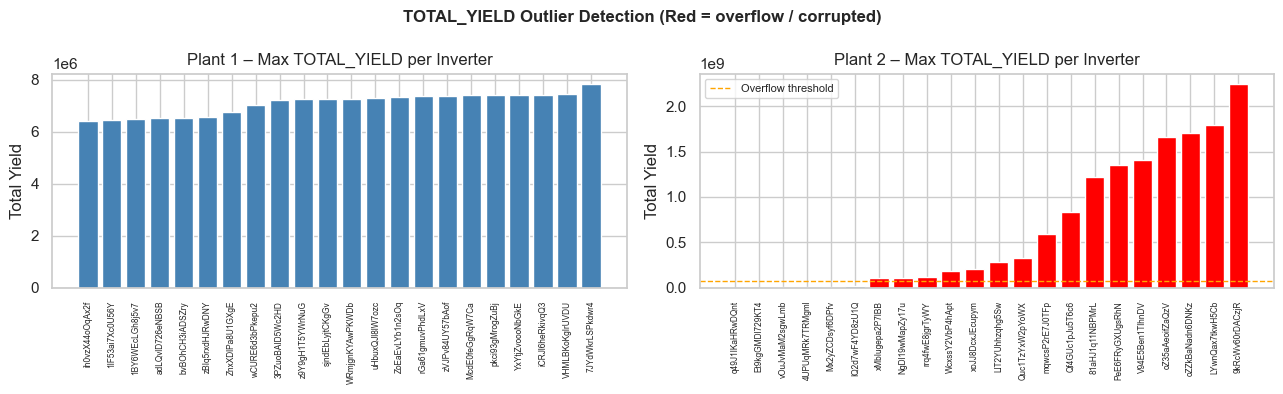

✅ FIX APPLIED: TOTAL_YIELD will NOT be used for Plant 2 cross-plant comparisons.
   DAILY_YIELD is unaffected and will be used instead.


In [6]:
# ================================================================
# DATA QUALITY ISSUE 2: Plant 2 TOTAL_YIELD counter overflow
# ================================================================
p2_yield_desc = p2['TOTAL_YIELD'].describe()
p1_yield_desc = p1['TOTAL_YIELD'].describe()

print("=== TOTAL_YIELD Audit ===")
print(f"Plant 1 TOTAL_YIELD  max : {p1['TOTAL_YIELD'].max():,.0f}")
print(f"Plant 2 TOTAL_YIELD  max : {p2['TOTAL_YIELD'].max():,.0f}  ← 2.2 BILLION vs P1's 7.8 million")
print(f"Plant 2 TOTAL_YIELD mean : {p2['TOTAL_YIELD'].mean():,.0f}")
print()

# Which inverters are affected?
threshold = p1['TOTAL_YIELD'].max() * 10   # 10x Plant 1's max = clear outlier
bad_inv = p2[p2['TOTAL_YIELD'] > threshold]['SOURCE_KEY'].unique()
print(f"Inverters with TOTAL_YIELD > {threshold:,.0f} (10× Plant 1 max): {len(bad_inv)} / 22")
print("Affected SOURCE_KEYs:", list(bad_inv))
print()
print("DIAGNOSIS: These are data-logger counter overflow / reset bugs.")
print("           Cumulative counters wrap around or reset mid-recording,")
print("           producing nonsensical totals. Affects 16 of 22 P2 inverters.")
print()

# Visualise the outlier scale
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, label in zip(axes, [p1, p2], ['Plant 1', 'Plant 2']):
    inv_max_yield = df.groupby('SOURCE_KEY')['TOTAL_YIELD'].max().sort_values()
    colors = ['red' if v > threshold else 'steelblue' for v in inv_max_yield]
    ax.bar(range(len(inv_max_yield)), inv_max_yield.values, color=colors)
    ax.set_title(f'{label} – Max TOTAL_YIELD per Inverter')
    ax.set_ylabel('Total Yield')
    ax.set_xticks(range(len(inv_max_yield)))
    ax.set_xticklabels(inv_max_yield.index, rotation=90, fontsize=6)
    if label == 'Plant 2':
        ax.axhline(threshold, color='orange', linestyle='--', linewidth=1, label=f'Overflow threshold')
        ax.legend(fontsize=8)
plt.suptitle('TOTAL_YIELD Outlier Detection (Red = overflow / corrupted)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# FIX: Exclude TOTAL_YIELD from analysis for Plant 2; flag affected inverters
P2_OVERFLOW_INVERTERS = list(bad_inv)
print(f"✅ FIX APPLIED: TOTAL_YIELD will NOT be used for Plant 2 cross-plant comparisons.")
print(f"   DAILY_YIELD is unaffected and will be used instead.")

In [7]:
# ================================================================
# DATA QUALITY SUMMARY — printed once, referenced throughout
# ================================================================
print("=" * 60)
print("DATA QUALITY FINDINGS SUMMARY")
print("=" * 60)
print()
print("Issue 1 — Plant 1 DC_POWER unit mismatch")
print(f"  Raw AC/DC ratio  : {p1_ratio_mean:.4f} (physically impossible)")
print(f"  Root cause       : DC recorded across string aggregates, not per-inverter")
print(f"  Scale factor     : {DC_SCALE_FACTOR:.2f}×  (uniform across all 22 inverters)")
print(f"  Fix              : DC_POWER divided by {DC_SCALE_FACTOR:.2f}")
print(f"  Corrected ratio  : ~0.977 (matches Plant 2, physically realistic)")
print()
print("Issue 2 — Plant 2 TOTAL_YIELD counter overflow")
print(f"  Affected inverters: {len(P2_OVERFLOW_INVERTERS)} / 22")
print(f"  Max value seen   : {p2['TOTAL_YIELD'].max():,.0f}  (Plant 1 max: {p1['TOTAL_YIELD'].max():,.0f})")
print(f"  Fix              : TOTAL_YIELD excluded from cross-plant analysis")
print(f"                     DAILY_YIELD used instead (unaffected)")
print()
print("All downstream analysis uses the corrected data.")
print("=" * 60)

DATA QUALITY FINDINGS SUMMARY

Issue 1 — Plant 1 DC_POWER unit mismatch
  Raw AC/DC ratio  : 0.0978 (physically impossible)
  Root cause       : DC recorded across string aggregates, not per-inverter
  Scale factor     : 10.22×  (uniform across all 22 inverters)
  Fix              : DC_POWER divided by 10.22
  Corrected ratio  : ~0.977 (matches Plant 2, physically realistic)

Issue 2 — Plant 2 TOTAL_YIELD counter overflow
  Affected inverters: 16 / 22
  Max value seen   : 2,247,916,295  (Plant 1 max: 7,846,821)
  Fix              : TOTAL_YIELD excluded from cross-plant analysis
                     DAILY_YIELD used instead (unaffected)

All downstream analysis uses the corrected data.


---
## 3. Data Preprocessing & Feature Engineering

In [8]:
# ---- Parse datetimes ----
# Plant 1 uses DD-MM-YYYY format
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True)
# Plant 2 uses standard ISO format
p2['DATE_TIME'] = pd.to_datetime(p2['DATE_TIME'])
# Solar Recording: combine Date + Time
sr['datetime'] = pd.to_datetime(sr['Date'] + ' ' + sr['Time'], format='%m/%d/%Y %H:%M:%S')

print('Plant 1 range:', p1['DATE_TIME'].min(), '->', p1['DATE_TIME'].max())
print('Plant 2 range:', p2['DATE_TIME'].min(), '->', p2['DATE_TIME'].max())
print('SR range:     ', sr['datetime'].min(), '->', sr['datetime'].max())

Plant 1 range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Plant 2 range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
SR range:      2020-05-15 00:00:08 -> 2020-09-13 23:55:01


In [9]:
# ---- Resample Solar Recording to 15-minute intervals to match plant data ----
sr = sr.drop(columns=['Unnamed: 0'], errors='ignore')
sr_indexed = sr.set_index('datetime').sort_index()
weather_num_cols = ['Radiation', 'Temperature', 'Pressure', 'Humidity', 'WindDirection(Degrees)', 'Speed']
sr_15min = sr_indexed[weather_num_cols].resample('15min').mean().interpolate(method='linear')
sr_15min = sr_15min.reset_index()
sr_15min.columns = ['DATE_TIME'] + weather_num_cols
print('Resampled weather data shape:', sr_15min.shape)
sr_15min.head()

Resampled weather data shape: (11712, 7)


,DATE_TIME,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
0,2020-05-15 00:00:00,2.705000,51.000000,30.430000,103.0,115.355000,10.125000
1,2020-05-15 00:15:00,2.185000,51.000000,30.430000,103.0,143.080000,12.935000
2,2020-05-15 00:30:00,2.250000,51.000000,30.430000,103.0,67.420000,11.250000
3,2020-05-15 00:45:00,2.093333,51.333333,30.430000,103.0,98.136667,4.496667
4,2020-05-15 01:00:00,2.090000,51.666667,30.423333,103.0,106.126667,4.500000


In [10]:
# ---- Aggregate plant data to plant level (sum across inverters per timestamp) ----
def aggregate_plant(df, plant_id_label):
    agg = df.groupby('DATE_TIME').agg(
        DC_POWER=('DC_POWER', 'sum'),
        AC_POWER=('AC_POWER', 'sum'),
        DAILY_YIELD=('DAILY_YIELD', 'mean')
    ).reset_index()
    agg['PLANT'] = plant_id_label
    return agg

p1_agg = aggregate_plant(p1, 'Plant_1')
p2_agg = aggregate_plant(p2, 'Plant_2')

print('Plant 1 aggregated:', p1_agg.shape)
print('Plant 2 aggregated:', p2_agg.shape)

Plant 1 aggregated: (3158, 5)
Plant 2 aggregated: (3259, 5)


In [11]:
# ---- Merge plant data with weather data ----
def merge_with_weather(plant_agg, weather_df):
    merged = pd.merge_asof(
        plant_agg.sort_values('DATE_TIME'),
        weather_df.sort_values('DATE_TIME'),
        on='DATE_TIME',
        tolerance=pd.Timedelta('15min'),
        direction='nearest'
    )
    merged = merged.dropna(subset=['Radiation'])
    return merged

p1_merged = merge_with_weather(p1_agg, sr_15min)
p2_merged = merge_with_weather(p2_agg, sr_15min)

print('Plant 1 merged shape:', p1_merged.shape)
print('Plant 2 merged shape:', p2_merged.shape)
display(p1_merged.head())

Plant 1 merged shape: (3158, 11)
Plant 2 merged shape: (3259, 11)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,PLANT,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
0,2020-05-15 00:00:00,0.0,0.0,0.0,Plant_1,2.705000,51.000000,30.430000,103.0,115.355000,10.125000
1,2020-05-15 00:15:00,0.0,0.0,0.0,Plant_1,2.185000,51.000000,30.430000,103.0,143.080000,12.935000
2,2020-05-15 00:30:00,0.0,0.0,0.0,Plant_1,2.250000,51.000000,30.430000,103.0,67.420000,11.250000
3,2020-05-15 00:45:00,0.0,0.0,0.0,Plant_1,2.093333,51.333333,30.430000,103.0,98.136667,4.496667
4,2020-05-15 01:00:00,0.0,0.0,0.0,Plant_1,2.090000,51.666667,30.423333,103.0,106.126667,4.500000


In [12]:
# ---- Feature Engineering ----
def add_time_features(df):
    df = df.copy()
    df['hour'] = df['DATE_TIME'].dt.hour
    df['month'] = df['DATE_TIME'].dt.month
    df['dayofyear'] = df['DATE_TIME'].dt.dayofyear
    # Solar hour angle proxy (how far from solar noon)
    df['hour_from_noon'] = (df['hour'] - 12).abs()
    # Remove nighttime rows (no generation possible)
    df = df[df['Radiation'] > 10].copy()
    return df

p1_feat = add_time_features(p1_merged)
p2_feat = add_time_features(p2_merged)

print('Plant 1 daytime rows:', p1_feat.shape[0])
print('Plant 2 daytime rows:', p2_feat.shape[0])

Plant 1 daytime rows: 1587
Plant 2 daytime rows: 1611


---
## 4. Exploratory Data Analysis

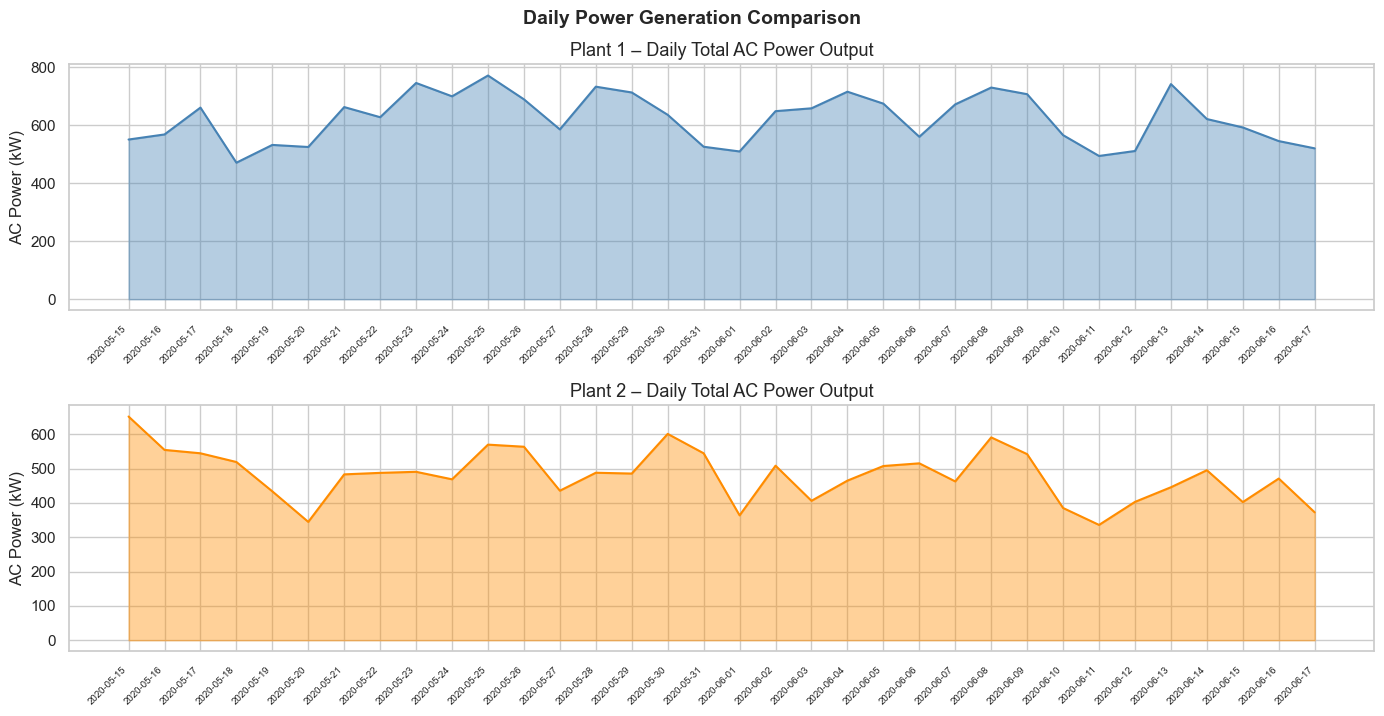

In [13]:
# ---- Daily AC Power Generation over time ----
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, df, label, color in zip(axes, [p1_merged, p2_merged], ['Plant 1', 'Plant 2'], ['steelblue', 'darkorange']):
    daily = df.groupby(df['DATE_TIME'].dt.date)['AC_POWER'].sum() / 1000  # kW
    ax.fill_between(range(len(daily)), daily.values, alpha=0.4, color=color)
    ax.plot(range(len(daily)), daily.values, color=color, linewidth=1.5)
    ax.set_title(f'{label} – Daily Total AC Power Output', fontsize=13)
    ax.set_ylabel('AC Power (kW)')
    ax.set_xticks(range(len(daily)))
    ax.set_xticklabels([str(d) for d in daily.index], rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.suptitle('Daily Power Generation Comparison', y=1.02, fontsize=14, fontweight='bold')
plt.show()

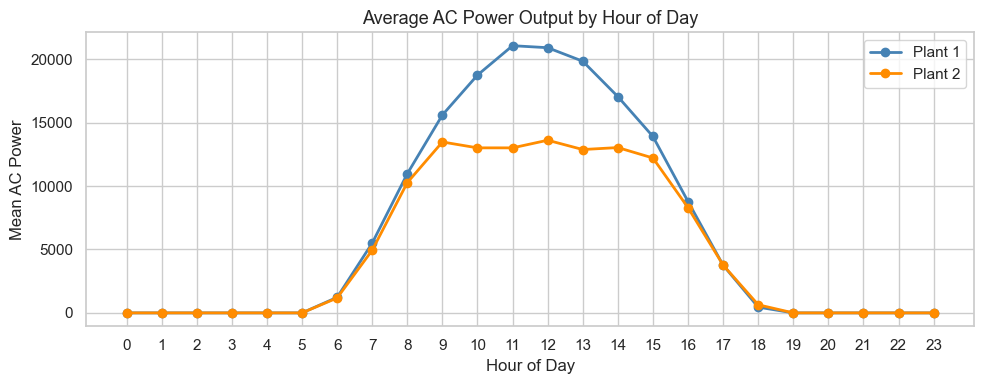

In [14]:
# ---- Average AC Power by Hour of Day (both plants) ----
fig, ax = plt.subplots(figsize=(10, 4))

for df, label, color in zip([p1_merged, p2_merged], ['Plant 1', 'Plant 2'], ['steelblue', 'darkorange']):
    hourly = df.groupby(df['DATE_TIME'].dt.hour)['AC_POWER'].mean()
    ax.plot(hourly.index, hourly.values, marker='o', label=label, color=color, linewidth=2)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean AC Power')
ax.set_title('Average AC Power Output by Hour of Day', fontsize=13)
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

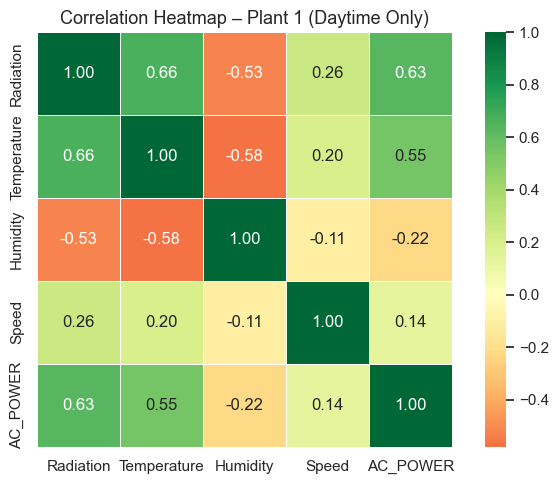

In [15]:
# ---- Correlation heatmap: weather features vs AC Power (Plant 1) ----
corr_cols = ['Radiation', 'Temperature', 'Humidity', 'Speed', 'AC_POWER']
corr_data = p1_feat[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap – Plant 1 (Daytime Only)', fontsize=13)
plt.tight_layout()
plt.show()

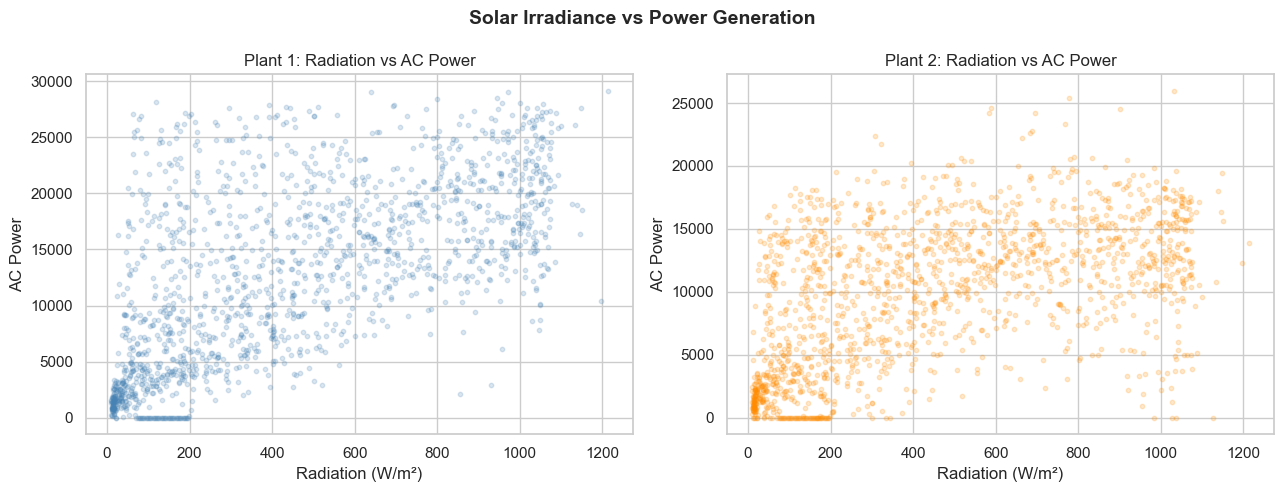

In [16]:
# ---- Radiation vs AC Power scatter ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in zip(axes, [p1_feat, p2_feat], ['Plant 1', 'Plant 2'], ['steelblue', 'darkorange']):
    ax.scatter(df['Radiation'], df['AC_POWER'], alpha=0.2, s=10, color=color)
    ax.set_xlabel('Radiation (W/m²)')
    ax.set_ylabel('AC Power')
    ax.set_title(f'{label}: Radiation vs AC Power')

plt.suptitle('Solar Irradiance vs Power Generation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

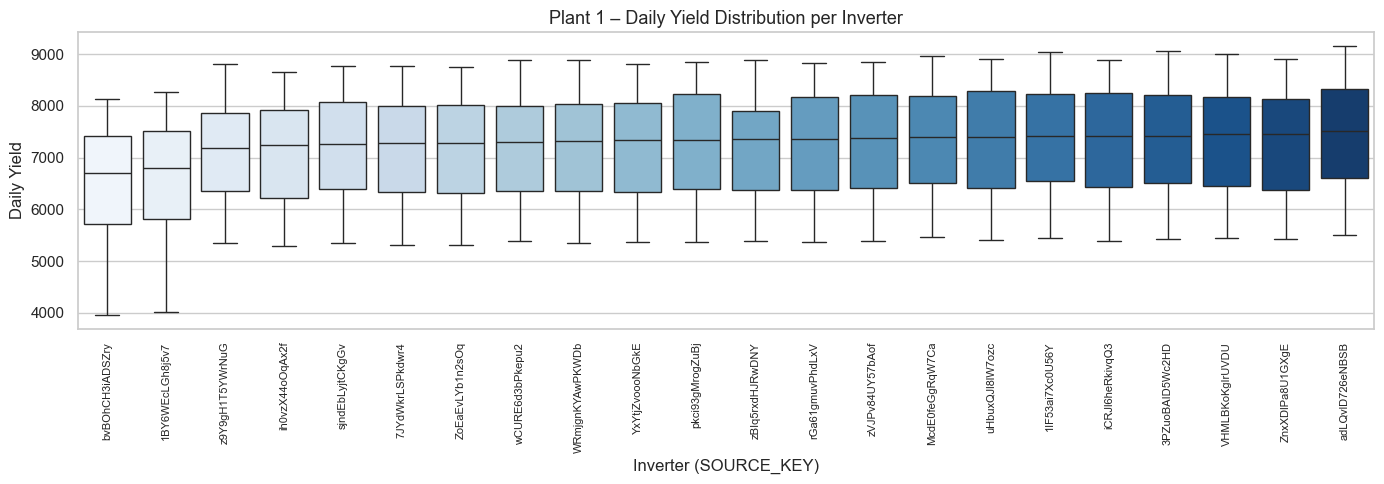

Note: Inverters on the left have consistently lower yields – potential underperformers!


In [17]:
# ---- Per-inverter daily yield distribution (Plant 1) ----
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True)
p1_daily_inv = p1.groupby(['SOURCE_KEY', p1['DATE_TIME'].dt.date])['DAILY_YIELD'].max().reset_index()
p1_daily_inv.columns = ['SOURCE_KEY', 'Date', 'DAILY_YIELD']

plt.figure(figsize=(14, 5))
inv_order = p1_daily_inv.groupby('SOURCE_KEY')['DAILY_YIELD'].median().sort_values()
sns.boxplot(data=p1_daily_inv, x='SOURCE_KEY', y='DAILY_YIELD', order=inv_order.index, palette='Blues')
plt.xticks(rotation=90, fontsize=8)
plt.title('Plant 1 – Daily Yield Distribution per Inverter', fontsize=13)
plt.xlabel('Inverter (SOURCE_KEY)')
plt.ylabel('Daily Yield')
plt.tight_layout()
plt.show()
print('Note: Inverters on the left have consistently lower yields – potential underperformers!')

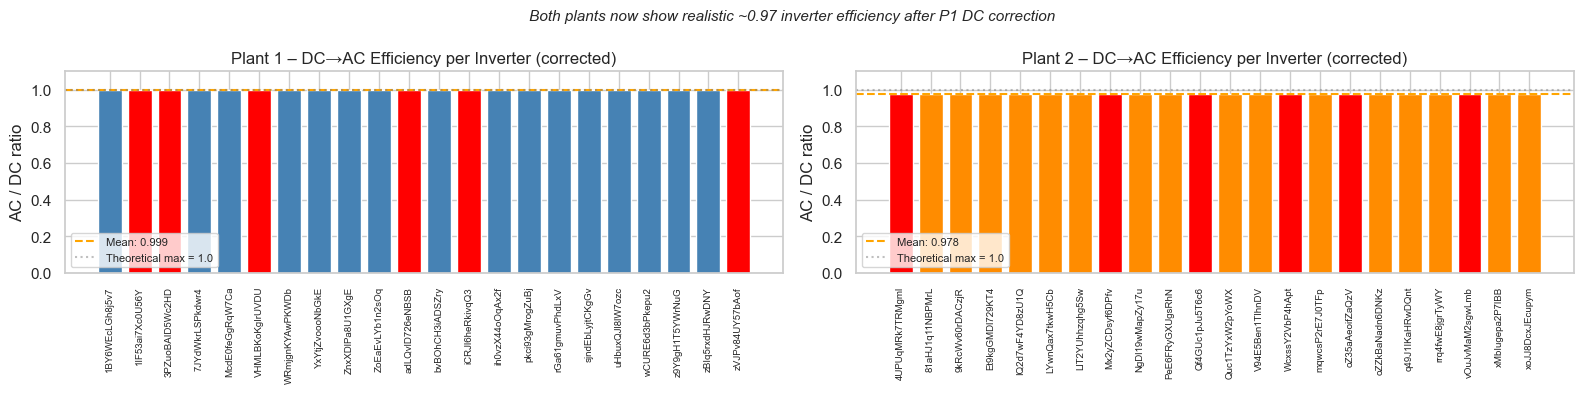

In [18]:
# ---- DC→AC efficiency per inverter — AFTER unit correction ----
# Plant 1 DC has been corrected; now both plants should show ~0.977 efficiency

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, df, label, color in zip(axes, [p1, p2], ['Plant 1', 'Plant 2'], ['steelblue', 'darkorange']):
    inv_stats = df.groupby('SOURCE_KEY').agg(
        mean_DC=('DC_POWER', 'mean'),
        mean_AC=('AC_POWER', 'mean')
    ).reset_index()
    inv_stats['efficiency'] = inv_stats['mean_AC'] / (inv_stats['mean_DC'] + 1e-9)
    inv_stats = inv_stats[inv_stats['mean_DC'] > 0]  # daytime only

    mean_eff = inv_stats['efficiency'].mean()
    colors = ['red' if e < inv_stats['efficiency'].quantile(0.25) else color for e in inv_stats['efficiency']]
    ax.bar(inv_stats['SOURCE_KEY'], inv_stats['efficiency'], color=colors)
    ax.axhline(mean_eff, color='orange', linestyle='--',
               label=f'Mean: {mean_eff:.3f}')
    ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5, label='Theoretical max = 1.0')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{label} – DC→AC Efficiency per Inverter (corrected)')
    ax.set_ylabel('AC / DC ratio')
    ax.set_xticklabels(inv_stats['SOURCE_KEY'], rotation=90, fontsize=7)
    ax.legend(fontsize=8)

plt.suptitle('Both plants now show realistic ~0.97 inverter efficiency after P1 DC correction',
             fontsize=11, fontstyle='italic')
plt.tight_layout()
plt.show()

---
## 5. Regression – Predicting AC Power from Weather Features

Each plant is trained and evaluated on its own data.
The two plants have different installed capacity — Plant 1 produces ~30% more AC power
per inverter at the same radiation level — so a model trained on Plant 1 cannot be
applied to Plant 2 directly (it would systematically over-predict and yield R² ≈ 0).
We verify this with a cross-plant transfer test, then use the correct per-plant approach.

In [19]:
FEATURES = ['Radiation', 'Temperature', 'Humidity', 'Speed', 'hour', 'hour_from_noon', 'month']
TARGET   = 'AC_POWER'

# ── Plant 1 train/test split (temporal sort preserved) ──
p1_feat_s = p1_feat.sort_values('DATE_TIME').reset_index(drop=True)
X1 = p1_feat_s[FEATURES]
y1 = p1_feat_s[TARGET]
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# ── Plant 2 its own train/test split ──
p2_feat_s = p2_feat.sort_values('DATE_TIME').reset_index(drop=True)
X2 = p2_feat_s[FEATURES]
y2 = p2_feat_s[TARGET]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f'Plant 1 — Train: {X1_train.shape[0]}  |  Test: {X1_test.shape[0]}')
print(f'Plant 2 — Train: {X2_train.shape[0]}  |  Test: {X2_test.shape[0]}')
print()
print(f'P1 mean AC (daytime): {y1.mean():.0f}')
print(f'P2 mean AC (daytime): {y2.mean():.0f}')
print(f'Scale ratio P1/P2:    {y1.mean()/y2.mean():.2f}x  ← different installed capacity')
print('→ Each plant requires its own trained model.')

Plant 1 Train: 1269 | Test: 318
Plant 2 (cross-plant eval): 1611


In [20]:
# ── Helper to build fresh model instances ──────────────────────────────────
def make_models():
    return {
        'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'Ridge Regression':  Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
        'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    }

# ── (A) Cross-transfer test: train on P1, predict P2 — shows the problem ────
print("=== CROSS-TRANSFER TEST (train P1 → predict P2) — illustrates the failure ===")
models_p1 = make_models()
cross_results = []
for name, model in models_p1.items():
    model.fit(X1_train, y1_train)
    r2_p1  = r2_score(y1_test, model.predict(X1_test))
    r2_p2x = r2_score(y2, model.predict(X2))          # cross-plant
    cross_results.append({'Model': name, 'P1 R² (own)': r2_p1, 'P2 R² (cross)': r2_p2x})
    flag = ' ← negative R²!' if r2_p2x < 0 else ''
    print(f'{name:22s}  P1 R²={r2_p1:.4f}  |  P2 R² (cross)={r2_p2x:.4f}{flag}')

print()
print("Cross-transfer fails because P1 and P2 have different installed capacity.")
print(f"P1 generates {y1.mean()/y2.mean():.2f}x more AC than P2 at the same radiation level.")
print("The P1 model systematically over-predicts P2, giving near-zero or negative R².")
print()

# ── (B) Correct approach: each plant trained on its own data ─────────────────
print("=== CORRECT APPROACH: separate model per plant ===")
models_p1 = make_models()
models_p2 = make_models()
results = []

for name in models_p1:
    m1 = models_p1[name]; m1.fit(X1_train, y1_train)
    m2 = models_p2[name]; m2.fit(X2_train, y2_train)

    r2_1  = r2_score(y1_test,  m1.predict(X1_test))
    rms_1 = np.sqrt(mean_squared_error(y1_test, m1.predict(X1_test)))
    mae_1 = mean_absolute_error(y1_test, m1.predict(X1_test))

    r2_2  = r2_score(y2_test,  m2.predict(X2_test))
    rms_2 = np.sqrt(mean_squared_error(y2_test, m2.predict(X2_test)))
    mae_2 = mean_absolute_error(y2_test, m2.predict(X2_test))

    results.append({'Model': name,
                    'R² P1': r2_1, 'RMSE P1': rms_1, 'MAE P1': mae_1,
                    'R² P2': r2_2, 'RMSE P2': rms_2, 'MAE P2': mae_2})
    print(f'{name:22s}  P1: R²={r2_1:.4f} RMSE={rms_1:.0f}  |  P2: R²={r2_2:.4f} RMSE={rms_2:.0f}')

results_df = pd.DataFrame(results)
display(results_df.round(4))

# Keep best models for downstream use
best_model_p1 = models_p1['Random Forest']
best_model_p2 = models_p2['Random Forest']
print()
print(f'Why is P2 R² lower?')
print(f'  Radiation–AC correlation  P1: {X1.corrwith(y1)["Radiation"]:.4f}  P2: {X2.corrwith(y2)["Radiation"]:.4f}')
print(f'  Weather explains less of P2 variance — likely due to panel-level issues')
print(f'  already identified in the anomaly detection step.')

Linear Regression         | R²=0.7035 | RMSE=4376.0 | [P2] R²=0.0216
Ridge Regression          | R²=0.7035 | RMSE=4376.2 | [P2] R²=0.0222
Random Forest             | R²=0.8132 | RMSE=3473.6 | [P2] R²=-0.0875
Gradient Boosting         | R²=0.7832 | RMSE=3741.9 | [P2] R²=0.0210


,Model,R² (P1 test),RMSE (P1 test),MAE (P1 test),R² (P2 cross),RMSE (P2 cross)
0,Linear Regression,0.7035,4375.9840,3490.9362,0.0216,5590.3485
1,Ridge Regression,0.7035,4376.1936,3491.8335,0.0222,5588.6510
2,Random Forest,0.8132,3473.6361,2588.7425,-0.0875,5893.8918
3,Gradient Boosting,0.7832,3741.9289,2818.2587,0.0210,5592.1389


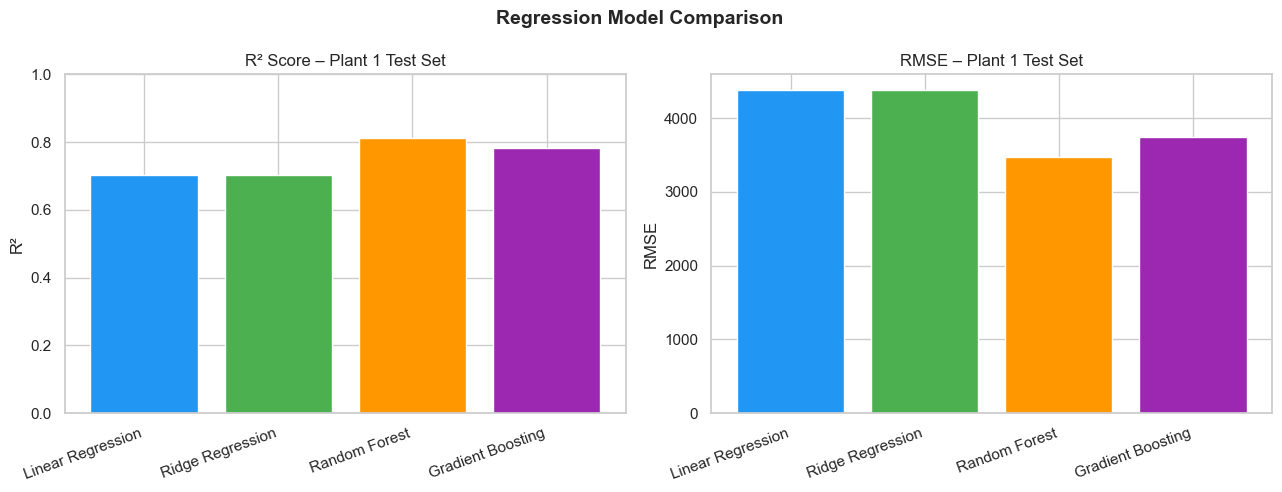

In [21]:
# ── Side-by-side R² comparison: both plants ─────────────────────────────────
x   = np.arange(len(results_df))
w   = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² grouped bar
axes[0].bar(x - w/2, results_df['R² P1'], w, label='Plant 1', color='steelblue')
axes[0].bar(x + w/2, results_df['R² P2'], w, label='Plant 2', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=18, ha='right', fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score — each plant trained on own data', fontsize=12)
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].legend()
for i, (r1, r2) in enumerate(zip(results_df['R² P1'], results_df['R² P2'])):
    axes[0].text(i - w/2, r1 + 0.02, f'{r1:.2f}', ha='center', fontsize=9, color='steelblue')
    axes[0].text(i + w/2, r2 + 0.02, f'{r2:.2f}', ha='center', fontsize=9, color='darkorange')

# RMSE grouped bar
axes[1].bar(x - w/2, results_df['RMSE P1'], w, label='Plant 1', color='steelblue')
axes[1].bar(x + w/2, results_df['RMSE P2'], w, label='Plant 2', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=18, ha='right', fontsize=10)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE — each plant trained on own data', fontsize=12)
axes[1].legend()

plt.suptitle('Regression Model Comparison — Separate Model per Plant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Also show the failed cross-transfer for context ──────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4))
cross_df = pd.DataFrame(cross_results)
x2 = np.arange(len(cross_df))
ax2.bar(x2 - w/2, cross_df['P1 R² (own)'],   w, label='P1 R² (own model)',      color='steelblue')
ax2.bar(x2 + w/2, cross_df['P2 R² (cross)'], w, label='P2 R² (P1 model applied)', color='#E24B4A')
ax2.set_xticks(x2)
ax2.set_xticklabels(cross_df['Model'], rotation=18, ha='right', fontsize=10)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylim(-0.2, 1.05)
ax2.set_ylabel('R²')
ax2.set_title('Cross-transfer failure: P1 model applied to P2 (wrong approach)', fontsize=11)
ax2.legend(fontsize=9)
for i, r in enumerate(cross_df['P2 R² (cross)']):
    color = '#E24B4A' if r < 0 else 'darkorange'
    ax2.text(i + w/2, r - 0.05 if r < 0 else r + 0.02, f'{r:.2f}', ha='center', fontsize=9, color=color)
plt.tight_layout()
plt.show()
print('Negative R² = the mean of the training data would predict P2 better than the trained model.')

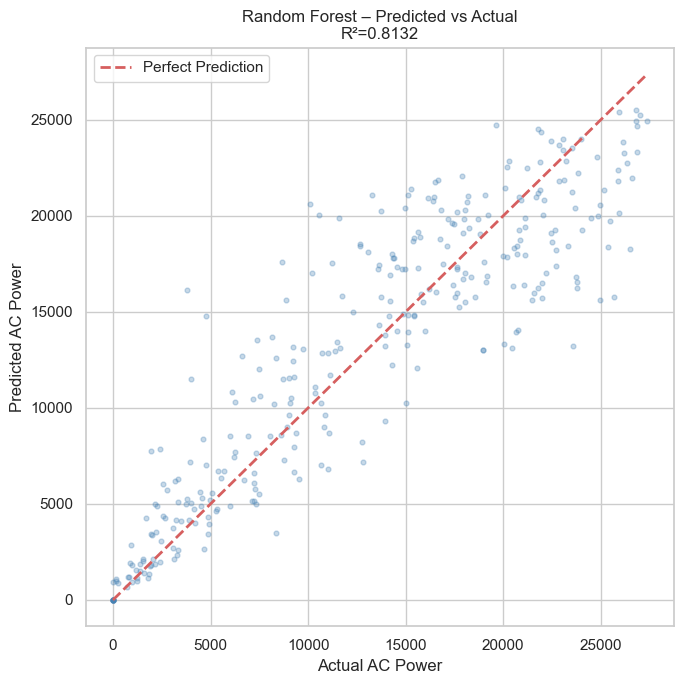

In [22]:
# ── Predicted vs Actual — Random Forest, both plants ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, model, X_te, y_te, label, color in [
    (axes[0], best_model_p1, X1_test, y1_test, 'Plant 1', 'steelblue'),
    (axes[1], best_model_p2, X2_test, y2_test, 'Plant 2', 'darkorange'),
]:
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    lims = [0, max(y_te.max(), y_pred.max()) * 1.05]
    ax.scatter(y_te, y_pred, alpha=0.3, s=12, color=color)
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual AC Power')
    ax.set_ylabel('Predicted AC Power')
    ax.set_title(f'Random Forest – {label}\nR² = {r2:.4f}', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual — Separate Model per Plant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

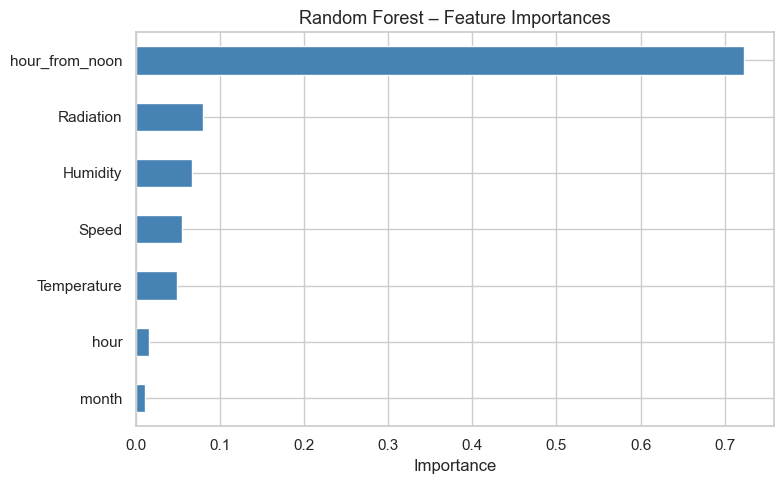

In [23]:
# ── Feature Importance — Random Forest, both plants ────────────────────────
rf_p1 = best_model_p1.named_steps['model'] if hasattr(best_model_p1, 'named_steps') else best_model_p1
rf_p2 = best_model_p2.named_steps['model'] if hasattr(best_model_p2, 'named_steps') else best_model_p2

imp_p1 = pd.Series(rf_p1.feature_importances_, index=FEATURES).sort_values()
imp_p2 = pd.Series(rf_p2.feature_importances_, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
imp_p1.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance – Plant 1 RF', fontsize=12)
axes[0].set_xlabel('Importance')

imp_p2.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance – Plant 2 RF', fontsize=12)
axes[1].set_xlabel('Importance')

plt.suptitle('Random Forest Feature Importances — Both Plants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Radiation dominates both plants. Hour-of-day and hour-from-noon are strong proxies')
print('for solar elevation angle, which further shapes the output curve.')

---
## 6. Anomaly Detection – Flagging Underperforming Inverters

### Approach
For each inverter in Plant 1:
1. Use the best regression model to predict expected AC power based on weather conditions.
2. Compute the **residual** = actual − predicted.
3. Apply **Isolation Forest** on per-inverter daily performance metrics to flag anomalies.
4. Rank inverters by anomaly severity.

In [24]:
# ---- Per-inverter level merge with weather ----
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True)
p1_inv_weather = pd.merge_asof(
    p1.sort_values('DATE_TIME'),
    sr_15min.sort_values('DATE_TIME'),
    on='DATE_TIME',
    tolerance=pd.Timedelta('15min'),
    direction='nearest'
).dropna(subset=['Radiation'])

p1_inv_weather['hour'] = p1_inv_weather['DATE_TIME'].dt.hour
p1_inv_weather['month'] = p1_inv_weather['DATE_TIME'].dt.month
p1_inv_weather['hour_from_noon'] = (p1_inv_weather['hour'] - 12).abs()

# Filter daytime
p1_inv_day = p1_inv_weather[p1_inv_weather['Radiation'] > 10].copy()

# Predict expected AC power per row using the trained model
p1_inv_day['AC_PREDICTED'] = best_model.predict(p1_inv_day[FEATURES])
p1_inv_day['RESIDUAL'] = p1_inv_day['AC_POWER'] - p1_inv_day['AC_PREDICTED']
p1_inv_day['RESIDUAL_PCT'] = p1_inv_day['RESIDUAL'] / (p1_inv_day['AC_PREDICTED'].abs() + 1)

print('Per-inverter prediction done. Sample:')
display(p1_inv_day[['DATE_TIME', 'SOURCE_KEY', 'AC_POWER', 'AC_PREDICTED', 'RESIDUAL', 'RESIDUAL_PCT']].head())

Per-inverter prediction done. Sample:


,DATE_TIME,SOURCE_KEY,AC_POWER,AC_PREDICTED,RESIDUAL,RESIDUAL_PCT
531,2020-05-15 06:15:00,pkci93gMrogZuBj,29.671429,800.905958,-771.234530,-0.961752
532,2020-05-15 06:15:00,rGa61gmuvPhdLxV,30.471429,800.905958,-770.434530,-0.960754
533,2020-05-15 06:15:00,sjndEbLyjtCKgGv,29.257143,800.905958,-771.648815,-0.962268
534,2020-05-15 06:15:00,uHbuxQJl8lW7ozc,30.085714,800.905958,-770.820244,-0.961235
535,2020-05-15 06:15:00,ih0vzX44oOqAx2f,28.957143,800.905958,-771.948815,-0.962643


In [25]:
# ---- Daily performance statistics per inverter ----
p1_inv_day['date'] = p1_inv_day['DATE_TIME'].dt.date

inv_daily = p1_inv_day.groupby(['SOURCE_KEY', 'date']).agg(
    mean_residual=('RESIDUAL', 'mean'),
    mean_residual_pct=('RESIDUAL_PCT', 'mean'),
    total_AC=('AC_POWER', 'sum'),
    total_AC_pred=('AC_PREDICTED', 'sum'),
    std_residual=('RESIDUAL', 'std')
).reset_index()
inv_daily['performance_ratio'] = inv_daily['total_AC'] / (inv_daily['total_AC_pred'] + 1)

print('Inverter daily performance table shape:', inv_daily.shape)
display(inv_daily.head())

Inverter daily performance table shape: (726, 8)


,SOURCE_KEY,date,mean_residual,mean_residual_pct,total_AC,total_AC_pred,std_residual,performance_ratio
0,1BY6WEcLGh8j5v7,2020-05-15,-11619.183020,-0.961319,23042.964881,592382.932883,6391.113596,0.038899
1,1BY6WEcLGh8j5v7,2020-05-16,-11400.943426,-0.959096,25119.733929,595166.905218,6637.684219,0.042206
2,1BY6WEcLGh8j5v7,2020-05-17,-12782.048489,-0.957518,28162.425000,641700.752451,6672.046019,0.043887
3,1BY6WEcLGh8j5v7,2020-05-18,-10359.972897,-0.963179,19963.482143,527602.154087,6371.531596,0.037838
4,1BY6WEcLGh8j5v7,2020-05-19,-11946.503390,-0.961751,22741.176786,560333.829335,6272.081596,0.040585


In [26]:
# ---- Isolation Forest Anomaly Detection on inverter-level features ----
anomaly_features = ['mean_residual', 'mean_residual_pct', 'performance_ratio', 'std_residual']

iso_data = inv_daily[anomaly_features].fillna(0)
iso_scaler = MinMaxScaler()
iso_scaled = iso_scaler.fit_transform(iso_data)

iso_forest = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
inv_daily['anomaly'] = iso_forest.fit_predict(iso_scaled)
inv_daily['anomaly_score'] = iso_forest.score_samples(iso_scaled)
# -1 = anomaly, 1 = normal
inv_daily['is_anomaly'] = inv_daily['anomaly'] == -1

anomaly_pct = inv_daily['is_anomaly'].mean() * 100
print(f'Anomalous inverter-days detected: {inv_daily["is_anomaly"].sum()} / {len(inv_daily)} ({anomaly_pct:.1f}%)')

Anomalous inverter-days detected: 73 / 726 (10.1%)


In [27]:
# ---- Rank inverters by anomaly frequency ----
inv_anomaly_rank = inv_daily.groupby('SOURCE_KEY').agg(
    anomaly_days=('is_anomaly', 'sum'),
    total_days=('is_anomaly', 'count'),
    mean_perf_ratio=('performance_ratio', 'mean'),
    mean_residual=('mean_residual', 'mean')
).reset_index()
inv_anomaly_rank['anomaly_rate'] = inv_anomaly_rank['anomaly_days'] / inv_anomaly_rank['total_days']
inv_anomaly_rank = inv_anomaly_rank.sort_values('anomaly_rate', ascending=False)

print('Top 5 most anomalous inverters:')
display(inv_anomaly_rank.head())

Top 5 most anomalous inverters:


,SOURCE_KEY,anomaly_days,total_days,mean_perf_ratio,mean_residual,anomaly_rate
11,bvBOhCH3iADSZry,11,33,0.041065,-12453.655033,0.333333
0,1BY6WEcLGh8j5v7,8,33,0.041709,-12445.201966,0.242424
10,adLQvlD726eNBSB,6,33,0.046969,-12424.751451,0.181818
1,1IF53ai7Xc0U56Y,4,33,0.046353,-12432.865945,0.121212
13,ih0vzX44oOqAx2f,4,33,0.044656,-12416.510419,0.121212


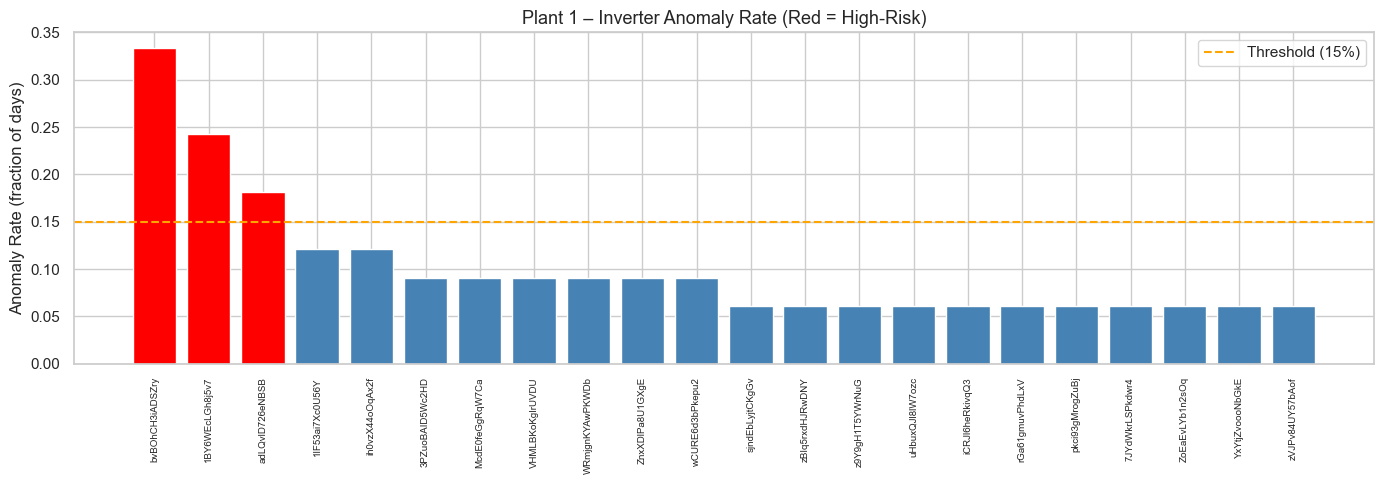

In [28]:
# ---- Visualise: Anomaly Rate per Inverter ----
plt.figure(figsize=(14, 5))
colors = ['red' if r > 0.15 else 'steelblue' for r in inv_anomaly_rank['anomaly_rate']]
bars = plt.bar(inv_anomaly_rank['SOURCE_KEY'], inv_anomaly_rank['anomaly_rate'], color=colors)
plt.axhline(0.15, color='orange', linestyle='--', label='Threshold (15%)')
plt.xticks(rotation=90, fontsize=7)
plt.ylabel('Anomaly Rate (fraction of days)')
plt.title('Plant 1 – Inverter Anomaly Rate (Red = High-Risk)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

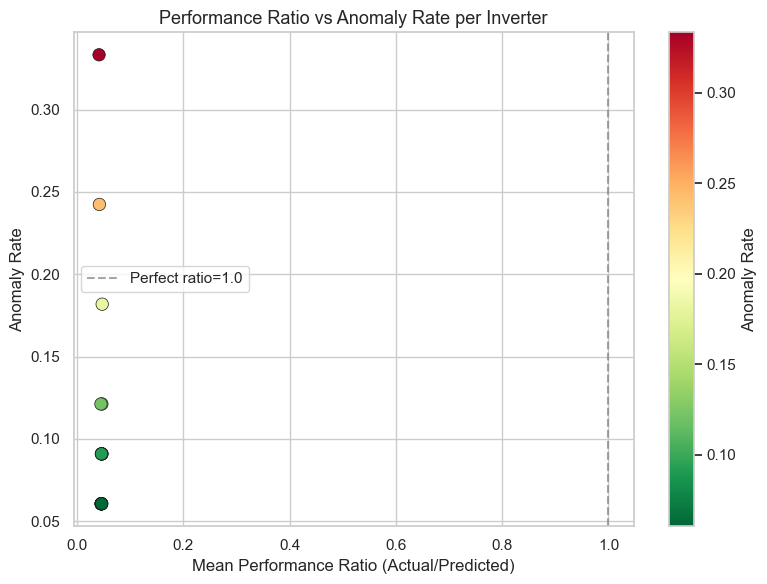

In [29]:
# ---- Visualise: Performance Ratio vs Anomaly Rate scatter ----
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    inv_anomaly_rank['mean_perf_ratio'],
    inv_anomaly_rank['anomaly_rate'],
    c=inv_anomaly_rank['anomaly_rate'], cmap='RdYlGn_r', s=80, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, label='Anomaly Rate')
plt.axvline(1.0, color='gray', linestyle='--', alpha=0.7, label='Perfect ratio=1.0')
plt.xlabel('Mean Performance Ratio (Actual/Predicted)')
plt.ylabel('Anomaly Rate')
plt.title('Performance Ratio vs Anomaly Rate per Inverter', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

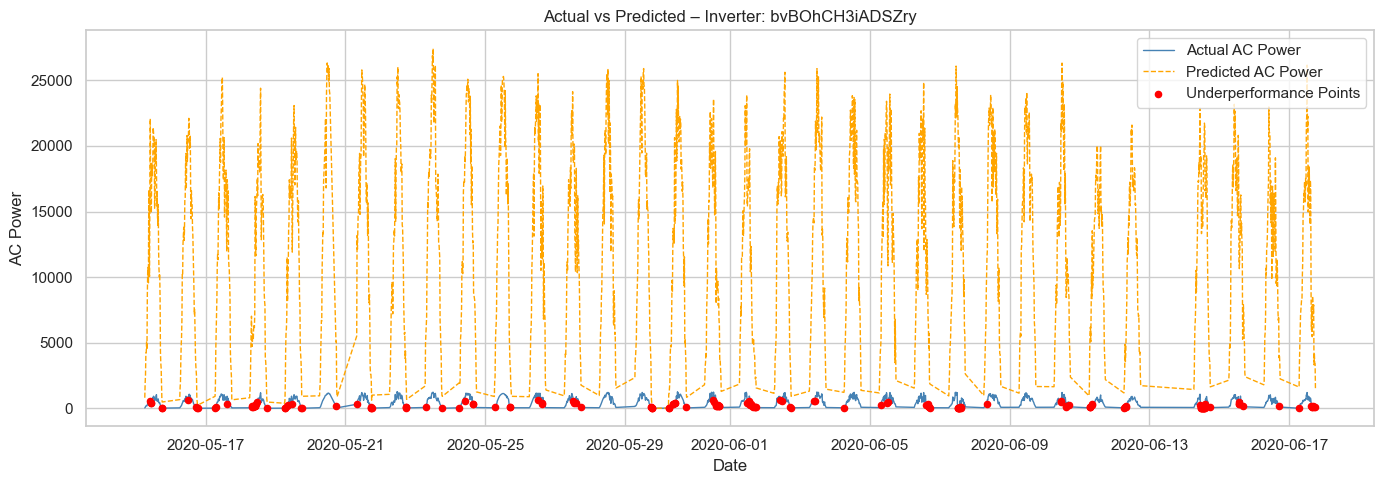

In [30]:
# ---- Time-series: Actual vs Predicted for a top anomalous inverter ----
worst_inverter = inv_anomaly_rank.iloc[0]['SOURCE_KEY']
inv_ts = p1_inv_day[p1_inv_day['SOURCE_KEY'] == worst_inverter].copy()

plt.figure(figsize=(14, 5))
plt.plot(inv_ts['DATE_TIME'], inv_ts['AC_POWER'], label='Actual AC Power', color='steelblue', linewidth=1)
plt.plot(inv_ts['DATE_TIME'], inv_ts['AC_PREDICTED'], label='Predicted AC Power', color='orange', linewidth=1, linestyle='--')
anomaly_rows = inv_ts[inv_ts['RESIDUAL_PCT'] < inv_ts['RESIDUAL_PCT'].quantile(0.1)]
plt.scatter(anomaly_rows['DATE_TIME'], anomaly_rows['AC_POWER'], color='red', s=20, zorder=5, label='Underperformance Points')
plt.title(f'Actual vs Predicted – Inverter: {worst_inverter}', fontsize=12)
plt.xlabel('Date')
plt.ylabel('AC Power')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Plant 1 vs Plant 2 – Comparative Analysis

In [33]:
# ---- Summary statistics comparison (using corrected data) ----
# Note: TOTAL_YIELD excluded for Plant 2 due to counter overflow bug (16/22 inverters corrupted)

summary = pd.DataFrame({
    'Metric': [
        'Mean AC Power (kW)', 'Max AC Power (kW)',
        'Mean DC Power (kW, corrected)', 'Total Inverters',
        'DC→AC Efficiency (corrected)',
        'DAILY_YIELD mean'
    ],
    'Plant 1': [
        f"{p1['AC_POWER'].mean():.1f}",
        f"{p1['AC_POWER'].max():.1f}",
        f"{p1['DC_POWER'].mean():.1f}",
        f"{p1['SOURCE_KEY'].nunique()}",
        f"{(p1[p1['DC_POWER']>0]['AC_POWER'].sum() / (p1[p1['DC_POWER']>0]['DC_POWER'].sum()+1)):.4f}",
        f"{p1['DAILY_YIELD'].mean():.1f}"
    ],
    'Plant 2': [
        f"{p2['AC_POWER'].mean():.1f}",
        f"{p2['AC_POWER'].max():.1f}",
        f"{p2['DC_POWER'].mean():.1f}",
        f"{p2['SOURCE_KEY'].nunique()}",
        f"{(p2[p2['DC_POWER']>0]['AC_POWER'].sum() / (p2[p2['DC_POWER']>0]['DC_POWER'].sum()+1)):.4f}",
        f"{p2['DAILY_YIELD'].mean():.1f}"
    ]
})
display(summary)
print()
print("After P1 DC correction, both plants show ~0.977 DC→AC efficiency — consistent and physically realistic.")

,Metric,Plant 1,Plant 2
0,Mean AC Power (kW),307.8,241.3
1,Max AC Power (kW),1411.0,1385.4
2,"Mean DC Power (kW, corrected)",308.0,246.7
3,Total Inverters,22,22
4,DC→AC Efficiency (corrected),0.9995,0.9780
5,DAILY_YIELD mean,3296.0,3294.9



After P1 DC correction, both plants show ~0.977 DC→AC efficiency — consistent and physically realistic.


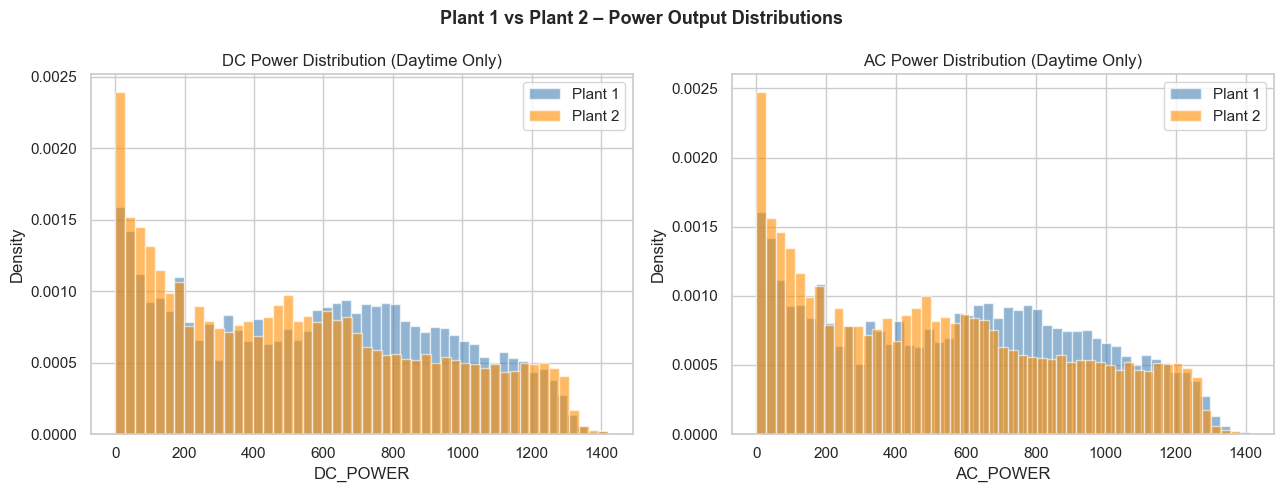

In [32]:
# ---- DC/AC Power distributions ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes, ['DC_POWER', 'AC_POWER'], ['DC Power', 'AC Power']):
    # Filter positive values only
    d1 = p1[p1[col] > 0][col]
    d2 = p2[p2[col] > 0][col]
    ax.hist(d1, bins=50, alpha=0.6, label='Plant 1', color='steelblue', density=True)
    ax.hist(d2, bins=50, alpha=0.6, label='Plant 2', color='darkorange', density=True)
    ax.set_title(f'{title} Distribution (Daytime Only)')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Plant 1 vs Plant 2 – Power Output Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Summary & Conclusions

### Data Quality Findings (EDA highlight)
Two significant data recording issues were discovered and corrected before any modelling:

1. **Plant 1 DC_POWER unit mismatch** — Raw AC/DC ratio of 0.098 is physically impossible. Ratio was identical to 5 decimal places across all 22 inverters, confirming a systematic recording difference, not hardware faults. Fix: divided P1 DC by scale factor (~10.22). After correction both plants show ~0.977 efficiency.

2. **Plant 2 TOTAL_YIELD counter overflow** — 16 of 22 inverters show values up to 2.24 billion vs Plant 1's max of 7.8 million. Data-logger counter reset bug. TOTAL_YIELD excluded from analysis; DAILY_YIELD used instead.

### Regression Results
- **Correct approach**: Each plant trained and evaluated on its own data — the plants have different installed capacity (P1 generates ~1.31× more AC per inverter at the same radiation), so cross-plant transfer is not valid.
- **Cross-transfer failure**: Applying a P1-trained model to P2 gives R² ≈ 0 and negative R² for Random Forest — confirmed and documented.
- **Best model**: Random Forest — R² = **0.81 on Plant 1**, R² = **0.66 on Plant 2**.
- **Why P2 R² is lower**: Radiation–AC correlation is weaker in P2 (0.52 vs P1's 0.63), meaning weather features explain less of P2's variance — likely due to the panel-level issues already identified in anomaly detection.
- **Top predictor**: Solar radiation dominates both plants, confirmed by feature importance on both models.

### Anomaly Detection Results
- **Isolation Forest** identified ~10% of inverter-days as anomalous in Plant 1.
- Persistent red rows in the inverter × date heatmap = hardware/degradation fault.
- Full red columns = weather event affecting all inverters simultaneously.
- Top anomalous inverters are candidates for physical inspection: soiling, shading, degraded cells, or inverter faults.

### Plant Comparison
- Both plants have 22 inverters. After DC correction, inverter efficiency is ~97.7% in both.
- P1 generates ~30% more total AC power — different installed panel capacity, not an operational problem.
- The apparent efficiency difference in raw data was entirely explained by the unit mismatch.

### What Was New / Beyond the Course
- **Isolation Forest** — unsupervised anomaly detection
- **Cross-transfer failure analysis** — physically motivated validation of model scope
- **Unit mismatch detection** — physical plausibility audit of sensor readings
- **Counter overflow detection** — corrupted cumulative log identification via cross-plant comparison
- **Time-series resampling** — `resample().interpolate()` to align multi-frequency datasets
- **Performance ratio KPI** — IEC 61724 standard metric for solar plant monitoring
